<a href="https://colab.research.google.com/github/KaanAkkok/Multi-armed-Contextual_Bandit_Experiments/blob/main/Multi_Armed_Bandit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from typing import override
from enum import Enum
from collections import deque

In [ ]:
class Q_method(str, Enum):
  SAMPLE_AVERAGE = "sample_average"
  CONSTANT_STEP_SIZE = "constant_step_size"
  RECENCY_WEIGHTED = "recency_weighted"
  SLIDING_WINDOW = "sliding_window"

In [ ]:
class Agent(ABC):
  def __init__(self, name: str):
        self.name = name

  def get_method(self, method: Q_method):
    method_mapper = {
        Q_method.SAMPLE_AVERAGE: self.sample_average,
        Q_method.CONSTANT_STEP_SIZE: self.constant_step_size,
        Q_method.RECENCY_WEIGHTED: self.recency_weighted,
        Q_method.SLIDING_WINDOW: self.sliding_window
    }
    if method not in method_mapper:
        raise ValueError(f"Invalid Q_method: {method}")
    return method_mapper[method]

  @abstractmethod
  def give_decision(self, reward: float | None, action: int | None, step: int, features: dict) -> int:
    pass

  @abstractmethod
  def sample_average(self, action: int, reward: float, **kwargs):
    pass

  @abstractmethod
  def constant_step_size(self, action: int, reward: float, **kwargs):
    pass

  @abstractmethod
  def recency_weighted(self, action: int, reward: float, **kwargs):
    pass

  @abstractmethod
  def sliding_window(self, action: int, reward: float, **kwargs):
    pass

  @abstractmethod
  def clear_all(self):
    pass

In [ ]:
class UCB(Agent):
  def __init__(
      self,
      arm: int,
      ucb_constant: float,
      Q_update_method: str | Q_method,
      alpha_constant: float = 0.1,
      gamma_constant: float = 0.6,
      w_constant: int = 1,
      optimistic: float = 0.0
  ):
    if isinstance(Q_update_method, str):
      Q_update_method = Q_update_method.lower().strip()
      if Q_update_method not in [e.value for e in Q_method]:
        raise ValueError(f"Invalid Q_update_method: {Q_update_method}\nSupported: {[e.value for e in Q_method]}")
    elif not isinstance(Q_update_method, Q_method):
      raise ValueError(f"Invalid Q_update_method: {Q_update_method}\nSupported: {[e.value for e in Q_method]}")
    self.arm = arm
    self.optimistic = optimistic
    self.Q = np.ones(arm) * self.optimistic
    self.N = np.zeros(arm)
    self.ucb_values = np.zeros(arm)
    self.ucb_constant = ucb_constant if ucb_constant is not None else 2
    self.method_name = Q_method(Q_update_method.lower().strip())
    self.Q_update_method = super().get_method(Q_method(Q_update_method.lower().strip()))
    super().__init__(f"UCB_{Q_method(Q_update_method.lower().strip()).value}")
    self.alpha = alpha_constant
    self.gamma = gamma_constant
    self.w = w_constant
    self.reward_history = [deque(maxlen=self.w) for _ in range(self.arm)]
    self.N_history = [deque(maxlen=self.w) for _ in range(self.arm)]

  @override
  def give_decision(self, reward: float | None, action: int | None, step: int, features: dict) -> int:
    if action is not None:
      self.Q_update_method(action=action, reward=reward, alpha=self.alpha, gamma=self.gamma, w=self.w)

    if self.method_name == Q_method.SLIDING_WINDOW:
      for arm in range(self.arm):
        N = sum(self.N_history[arm])
        if N == 0:
            self.ucb_values[arm] = float("inf")
            decision = np.argmax(self.ucb_values)
        else:
            self.ucb_values[arm] = (self.Q[arm] + self.ucb_constant * np.sqrt(np.log(step) / N))
            decision = np.argmax(self.ucb_values)
      return np.argmax(self.ucb_values)
    else:
      is_unattempted_action_exists = np.any(self.N == 0)
      if is_unattempted_action_exists:
        unattempted_actions = np.where(self.N == 0)[0]
        first_unattempted_action = unattempted_actions[0]
        return first_unattempted_action

      for arm in range(self.arm):
        self.ucb_values[arm] = self.Q[arm] + self.ucb_constant*np.sqrt(np.log(step)/self.N[arm])
      decision = np.argmax(self.ucb_values)

      return decision

  @override
  def sample_average(self, action: int, reward: float, **kwargs):
    self.N[action] += 1
    self.Q[action] += (1/self.N[action]) * (reward-self.Q[action])

  @override
  def constant_step_size(self, action: int, reward: float, **kwargs):
    self.N[action] += 1
    self.Q[action] += self.alpha * (reward-self.Q[action])

  @override
  def recency_weighted(self, action: int, reward: float, **kwargs):
    self.N[action] += 1
    self.Q[action] = (self.gamma * self.Q[action]) + ((1-self.gamma) * reward)

  @override
  def sliding_window(self, action: int, reward: float, **kwargs):
    """
    The current UCB exploration logic is incompatible with a sliding window approach.
    While Q-values might adapt to recent rewards,
    the action counter (N) accumulates globally from the start,
    causing the UCB exploration bonus to decay incorrectly in non-stationary settings.
    """
    self.N[action] += 1
    for arm in range(self.arm):
        if arm == action:
            self.N_history[arm].append(1)
        else:
            self.N_history[arm].append(0)
    self.reward_history[action].append(reward)
    self.Q[action] = np.mean(self.reward_history[action])

  @override
  def clear_all(self):
    self.N = np.zeros(self.arm)
    self.Q = np.ones(self.arm) * self.optimistic
    self.ucb_values = np.zeros(self.arm)
    self.reward_history = [deque(maxlen=self.w) for _ in range(self.arm)]
    self.N_history = [deque(maxlen=self.w) for _ in range(self.arm)]

In [ ]:
class LinUCB(Agent):
  def __init__(
      self,
      arm: int,
      linucb_constant: float,
      dim: int
  ):
    super().__init__("LinUCB(disjoint)")
    self.arm = arm
    self.linucb_constant = linucb_constant
    self.dim = dim
    self.linucb_values = np.zeros(arm)
    self.A = {}
    self.b = {}
    self.theta = {}

  @override
  def give_decision(self, reward: float | None, action: int | None, step: int, features: dict) -> int:
    if action is not None and reward is not None:
      if action not in self.A:
        self.A[action] = np.identity(self.dim)
        self.b[action] = np.zeros(self.dim)
      self.A[action] += np.outer(features[action], features[action])
      self.b[action] += reward * features[action]
    for arm_idx in range(self.arm):
      if arm_idx not in self.A:
        self.linucb_values[arm_idx] = float('inf')
      else:
        self.theta[arm_idx] = np.linalg.inv(self.A[arm_idx]).dot(self.b[arm_idx])
        feature_a = features[arm_idx]
        p_a = self.theta[arm_idx].T.dot(feature_a) + self.linucb_constant * np.sqrt(feature_a.T.dot(np.linalg.inv(self.A[arm_idx])).dot(feature_a))
        self.linucb_values[arm_idx] = p_a
    decision = np.argmax(self.linucb_values)
    return decision

  @override
  def sample_average(self, action: int, reward: float, **kwargs):
    pass

  @override
  def constant_step_size(self, action: int, reward: float, **kwargs):
    pass

  @override
  def recency_weighted(self, action: int, reward: float, **kwargs):
    pass

  @override
  def sliding_window(self, action: int, reward: float, **kwargs):
    pass

  @override
  def clear_all(self):
    self.A = {}
    self.b = {}
    self.theta = {}
    self.linucb_values = np.zeros(self.arm)

In [ ]:
class EpsilonGreedy(Agent):
  def __init__(
      self,
      arm: int,
      epsilon: float,
      Q_update_method: str | Q_method,
      alpha_constant: float = 0.1,
      gamma_constant: float = 0.6,
      w_constant: int = 1,
      optimistic: float = 0.0
  ):
    if isinstance(Q_update_method, str):
      Q_update_method = Q_update_method.lower().strip()
      if Q_update_method not in [e.value for e in Q_method]:
        raise ValueError(f"Invalid Q_update_method: {Q_update_method}\nSupported: {[e.value for e in Q_method]}")
    elif not isinstance(Q_update_method, Q_method):
      raise ValueError(f"Invalid Q_update_method: {Q_update_method}\nSupported: {[e.value for e in Q_method]}")
    self.arm = arm
    self.epsilon = epsilon
    self.optimistic = optimistic
    self.Q = np.ones(arm) * self.optimistic
    self.N = np.zeros(arm)
    self.Q_update_method = super().get_method(Q_method(Q_update_method.lower().strip()))
    super().__init__(f"EpsilonGreedy_{Q_method(Q_update_method.lower().strip()).value}")
    self.alpha = alpha_constant
    self.gamma = gamma_constant
    self.w = w_constant
    self.reward_history = [deque(maxlen=self.w) for _ in range(self.arm)]
    self.N_history = [deque(maxlen=self.w) for _ in range(self.arm)]

  @override
  def give_decision(self, reward: float | None, action: int | None, step: int, features: dict) -> int:
    if action is not None:
      self.Q_update_method(action=action, reward=reward, alpha=self.alpha, gamma=self.gamma, w=self.w)

    choose = np.random.random()
    if choose < self.epsilon:
      return np.random.randint(0, self.arm)
    else:
      return np.argmax(self.Q)

  @override
  def sample_average(self, action: int, reward: float, **kwargs):
    self.N[action] += 1
    self.Q[action] += (1/self.N[action]) * (reward-self.Q[action])

  @override
  def constant_step_size(self, action: int, reward: float, **kwargs):
    self.N[action] += 1
    self.Q[action] += self.alpha * (reward-self.Q[action])

  @override
  def recency_weighted(self, action: int, reward: float, **kwargs):
    self.N[action] += 1
    self.Q[action] = (self.gamma * self.Q[action]) + ((1-self.gamma) * reward)

  @override
  def sliding_window(self, action: int, reward: float, **kwargs):
    self.N[action] += 1
    self.N_history[action].append(self.N[action])
    self.reward_history[action].append(reward)
    self.Q[action] = np.mean(self.reward_history[action])

  @override
  def clear_all(self):
    self.N = np.zeros(self.arm)
    self.Q = np.ones(self.arm) * self.optimistic # Use self.optimistic

In [ ]:
class LinearThompsonSampling(Agent):
  def __init__(
      self,
      arm: int,
      dim: int,
      confidence: float,
      R: float = 1.0,
      total_step: int = 10000
  ):
    super().__init__("ThompsonSampling")
    self.arm = arm
    self.dim = dim
    self.B = np.identity(self.dim)
    self.u_hat = 0
    self.confidence = confidence
    self.R = R
    self.f = np.zeros(self.dim)
    self.total_step = total_step
    self.v = self.R*np.sqrt((9*self.dim)*np.log(self.total_step/self.confidence))

  @override
  def give_decision(self, reward: float | None, action: int | None, step: int, features: dict) -> int:
    if action is not None and reward is not None:
      self.B += np.outer(features[action], features[action])
      self.f += (reward * features[action])
    self.u_hat = np.linalg.inv(self.B).dot(self.f)
    rand_chosen = np.random.multivariate_normal(mean=self.u_hat, cov=self.v**2*np.linalg.inv(self.B))
    scores = np.array([np.dot(features[i], rand_chosen) for i in range(self.arm)])
    return np.argmax(scores)

  @override
  def sample_average(self, action: int, reward: float, **kwargs):
    pass

  @override
  def constant_step_size(self, action: int, reward: float, **kwargs):
    pass

  @override
  def recency_weighted(self, action: int, reward: float, **kwargs):
    pass

  @override
  def sliding_window(self, action: int, reward: float, **kwargs):
    pass

  @override
  def clear_all(self):
    self.B = np.identity(self.dim)
    self.f = np.zeros(self.dim)
    self.u_hat = 0

In [ ]:
class Environment:
  def __init__(self, arm: int, stationary: bool, q_mean: float, q_std_dev: float, f_mean: float, f_std_dev: float, dim: int):
    self.arm = arm
    self.stationary = stationary
    self.q_mean = q_mean
    self.q_std_dev = q_std_dev
    self.f_mean = f_mean
    self.f_std_dev = f_std_dev
    self.q = np.zeros(arm)
    self.dim = dim
    self.theta_star = np.random.normal(loc=self.f_mean, scale=self.f_std_dev, size=self.dim)
    self.arm_features = {}

  def initialize_features(self):
    for arm_idx in range(self.arm):
      self.arm_features[arm_idx] = np.random.normal(loc=self.f_mean, scale=self.f_std_dev, size=self.dim)

  def initialize_q(self):
    for arm_idx in range(self.arm):
      self.q[arm_idx] = np.dot(self.theta_star, self.arm_features[arm_idx])

  def update_q(self):
    self.q += np.random.normal(loc=self.q_mean, scale=self.q_std_dev, size=self.arm)

  def get_reward(self, action: int, r_std_dev: float = 1.0):
    return np.random.normal(loc=self.q[action], scale=r_std_dev)

  def run_single_experiment(self, steps: int, r_std_dev: float, agent: Agent):
    rewards = np.zeros(steps)
    optimal = np.zeros(steps)

    self.initialize_q()

    prev_reward = None
    prev_action = None

    for t in range(steps):
      action = agent.give_decision(prev_reward, prev_action, t + 1, self.arm_features)
      current_reward = self.get_reward(action, r_std_dev)

      rewards[t] = current_reward
      optimal[t] = (action == np.argmax(self.q))

      prev_reward = current_reward
      prev_action = action

      if not self.stationary:
        self.update_q()

    return rewards, optimal

  def run_multiple_experiments(self, agents: list[Agent], r_std_dev: float, runs: int = 2000, steps: int = 10_000):
    agents_rewards = {}
    agents_optimal = {}

    for agent in agents:
      rewards = np.zeros((runs, steps))
      optimal = np.zeros((runs, steps))

      for i in range(runs):
        agent.clear_all()

        r, o = self.run_single_experiment(steps, r_std_dev, agent)
        rewards[i] = r
        optimal[i] = o

      agents_rewards[agent.name] = rewards
      agents_optimal[agent.name] = optimal

    return agents_rewards, agents_optimal

  def plot_average_rewards(self, agents: list[Agent], colors: list, rewards: dict):
    fig, ax = plt.subplots(figsize=(12, 5))

    for idx, agent in enumerate(agents):
      if agent.name not in rewards:
        raise ValueError(f"Agent {agent.name} not found in rewards dictionary.")
      avg_rewards = np.mean(rewards[agent.name], axis=0)
      ax.plot(
          avg_rewards,
          color=colors[(idx%len(colors))],
          label=agent.name
      )

    ax.set_xlabel("Steps")
    ax.set_ylabel("Average Reward")
    ax.set_title("Average Reward Comparison")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

  def plot_optimal_actions_percentage(self, agents: list[Agent], colors: list, optimal: dict):
    fig, ax = plt.subplots(figsize=(12, 5))

    for idx, agent in enumerate(agents):
      if agent.name not in optimal:
        raise ValueError(f"Agent {agent.name} not found in optimal choose dictionary.")
      avg_optimal = np.mean(optimal[agent.name], axis=0)
      ax.plot(
          avg_optimal * 100,
          color=colors[(idx%len(colors))],
          label=agent.name
      )

    ax.set_xlabel("Steps")
    ax.set_ylabel("Optimal Action (%)")
    ax.set_title("Optimal Action Comparison")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

  def plot_multiple_experiments(self, agents: list[Agent], rewards: dict, optimal: dict, colors: list | None = None):
    if not rewards or not optimal:
      raise ValueError("Rewards and optimal dictionaries cannot be empty.")
    if len(rewards) != len(optimal):
      raise ValueError("Rewards and optimal dictionaries must have the same size.")
    if agents == []:
      raise ValueError("Agents cannot be empty.")
    colors = [
        "red",
        "blue",
        "green",
        "orange",
        "purple",
        "black",
        "deeppink",
        "brown",
        "cyan",
        "gold"
    ] if colors is None or colors == [] else colors
    self.plot_average_rewards(agents, colors, rewards)
    self.plot_optimal_actions_percentage(agents, colors, optimal)

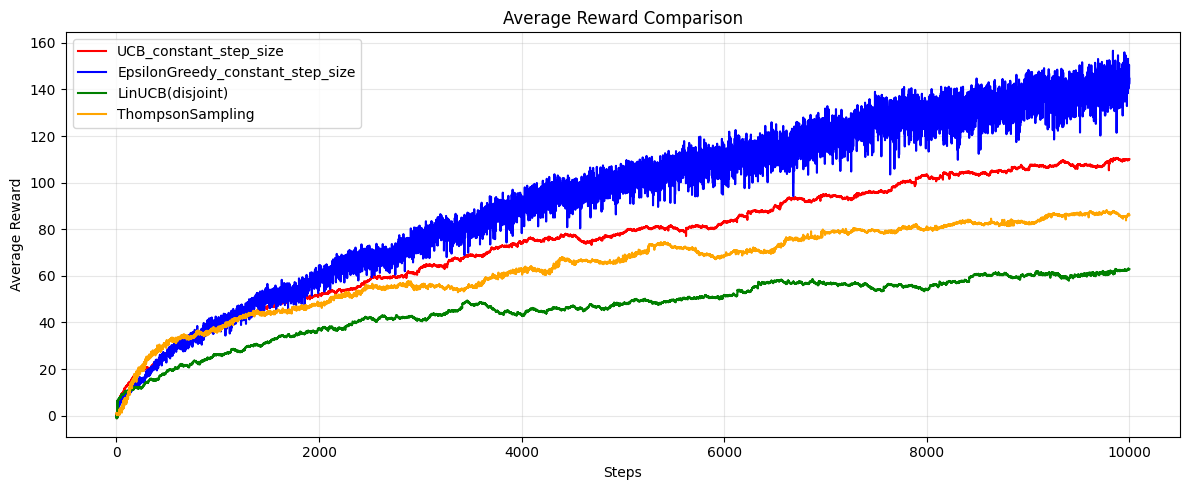

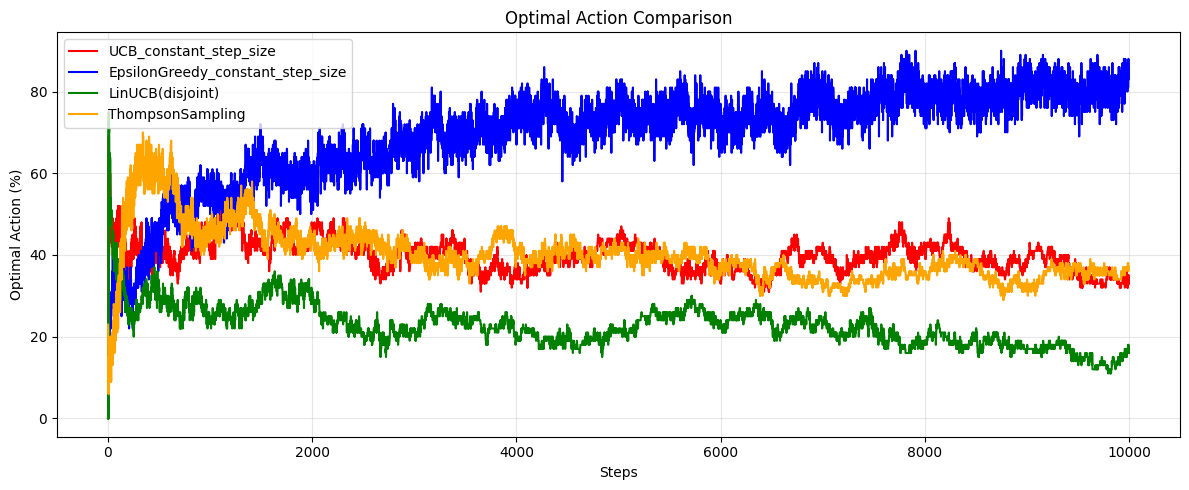

In [ ]:
# env settings
arm = 10
stationary = False
q_mean = 0.0
q_std_dev = 1.0
f_mean = 0.0
f_std_dev = 1.0
constant = 2
r_std_dev = 1.0
runs = 100
steps = 10000
dim = 10

# agent
agent_Q_method = Q_method.CONSTANT_STEP_SIZE
alpha = 0.1
gama = 0.6
epsilon = 0.1
optimistic = 0.0
w = 100

# AGENT ======================================================================================
ucb = UCB(
    arm=arm,
    ucb_constant=constant,
    Q_update_method=agent_Q_method,
    alpha_constant=alpha,
    gamma_constant=gama,
    w_constant=w,
    optimistic=optimistic
)
epsilon_greedy = EpsilonGreedy(
    arm=arm,
    epsilon=epsilon,
    Q_update_method=agent_Q_method,
    alpha_constant=alpha,
    gamma_constant=gama,
    w_constant=w,
    optimistic=optimistic
)
lin_ucb = LinUCB(
    arm=arm,
    linucb_constant=constant,
    dim=dim
)
thompson_sampling = LinearThompsonSampling(
    arm=arm,
    dim=dim,
    confidence=0.05,
    R=1.0,
    total_step=steps
)

agents = [ucb, epsilon_greedy, lin_ucb, thompson_sampling]

# ENV ========================================================================================
env = Environment(
    arm=arm,
    stationary=stationary,
    q_mean=q_mean,
    q_std_dev=q_std_dev,
    f_mean=f_mean,
    f_std_dev=f_std_dev,
    dim=dim
)

env.initialize_features()

# RUN MULTIPLE EXPERIMENTS ===================================================================
rewards, optimal = env.run_multiple_experiments(agents, r_std_dev, runs=runs, steps=steps)

# PLOT =======================================================================================
env.plot_multiple_experiments(agents, rewards, optimal)